# ***Machine Learning Classification Project***


* **Goal:** Build a machine learning system to accurately detect fraudulent credit card transactions while handling severe class imbalance.
* **Dataset:** [https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](http://)
* **Models Used:** Logistic Regression


# ***1. Import Required Libraries***

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import tempfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# ***2. Load the Dataset***

In [2]:
# ==============================
# LOAD DATASET
# ==============================
data = pd.read_csv("/kaggle/input/creditcard-csv/creditcard.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# ***3. Dataset Overview***

# ***3.1 - First Five Records***

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# ***3.2 - Dataset Information***

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# ***3.3 - Dataset Shape***

In [5]:
data.shape

(284807, 31)

# ***3.4 - Last Five Records***

In [6]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


# ***3.5 Statistical Summary***

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# ***4. Feature and Target Selection***

In [8]:
# ==============================
# FEATURES & TARGET
# ==============================
X = data.drop("Class", axis=1)
y = data["Class"]

In [9]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [10]:
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

# ***5. Train–Test Split***

In [11]:
# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)


# ***6. Feature Scaling***

In [12]:
# ==============================
# FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ***7. Logistic Regression Model***

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# ***8. Model Evaluation (Model Accuracy)***

In [14]:
# ==============================
# LOGISTIC REGRESSION MODEL
# ==============================
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9755275446789088

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



# ***9. Model Performance Visualization***

# *9.1 Confusion Matrix*

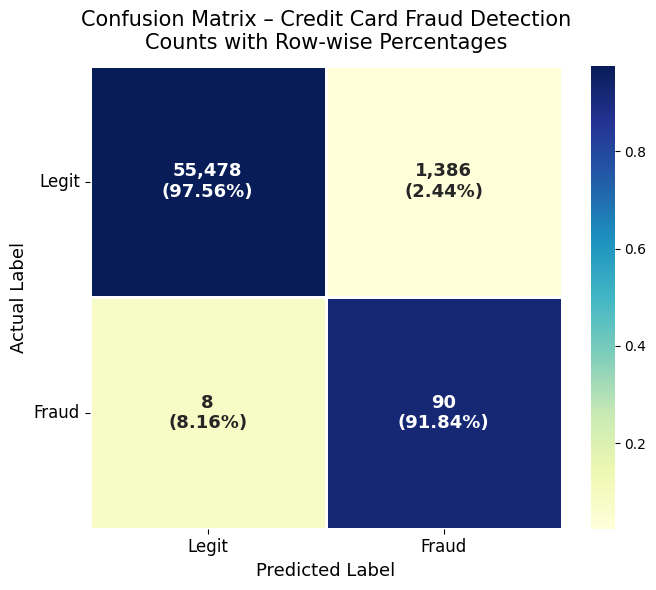

In [15]:
# ==============================
# CONFUSION MATRIX (EXPERT VERSION)
# ==============================
cm = confusion_matrix(y_test, y_pred)

# Convert to percentages
cm_percent = cm / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [f"{cm[0,0]:,}\n({cm_percent[0,0]*100:.2f}%)",
     f"{cm[0,1]:,}\n({cm_percent[0,1]*100:.2f}%)"],
    [f"{cm[1,0]:,}\n({cm_percent[1,0]*100:.2f}%)",
     f"{cm[1,1]:,}\n({cm_percent[1,1]*100:.2f}%)"]
])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    linewidths=2,
    linecolor="white",
    cbar=True,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("Actual Label", fontsize=13)
plt.title(
    "Confusion Matrix – Credit Card Fraud Detection\n"
    "Counts with Row-wise Percentages",
    fontsize=15,
    pad=12
)

plt.xticks([0.5, 1.5], ["Legit", "Fraud"], fontsize=12)
plt.yticks([0.5, 1.5], ["Legit", "Fraud"], rotation=0, fontsize=12)

plt.tight_layout()
plt.show()



# *9.2 CLASS DISTRIBUTION*

/tmp/ipykernel_17/3013981374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


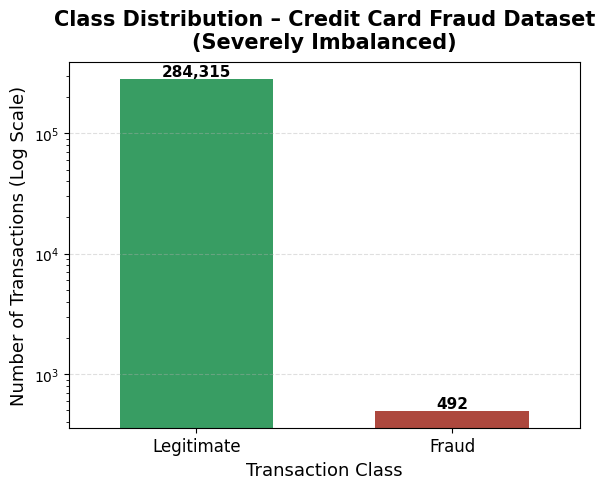

In [16]:
# ==============================
# CLASS DISTRIBUTION (EXPERT STYLE)
# ==============================
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    x=y,
    palette=["#27ae60", "#c0392b"],
    width=0.6
)

plt.yscale("log")

plt.xlabel("Transaction Class", fontsize=13)
plt.ylabel("Number of Transactions (Log Scale)", fontsize=13)
plt.title(
    "Class Distribution – Credit Card Fraud Dataset\n"
    "(Severely Imbalanced)",
    fontsize=15,
    weight="bold",
    pad=10
)

plt.xticks([0, 1], ["Legitimate", "Fraud"], fontsize=12)

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



# *9.3 ROC Curve and AUC Score*

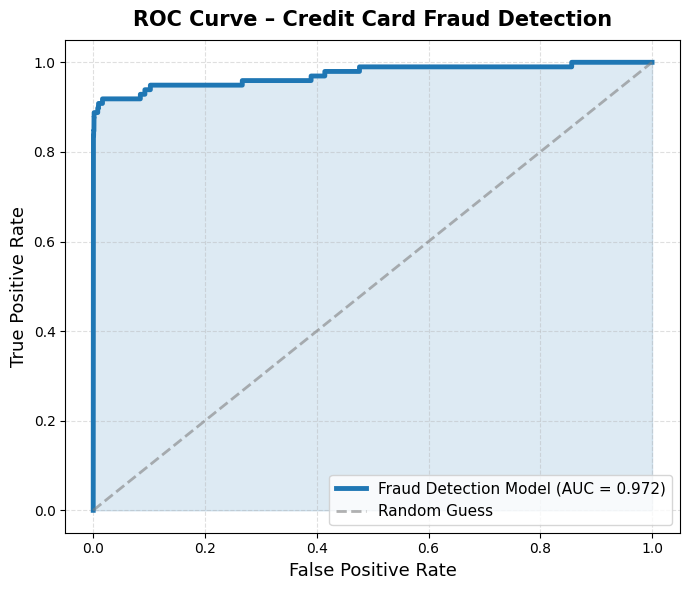

In [17]:
# ==============================
# ROC CURVE (EXPERT STYLE)
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    color="#1f77b4",
    linewidth=3.5,
    label=f"Fraud Detection Model (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=2,
    alpha=0.6,
    label="Random Guess"
)

plt.fill_between(fpr, tpr, alpha=0.15, color="#1f77b4")

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title(
    "ROC Curve – Credit Card Fraud Detection",
    fontsize=15,
    weight="bold",
    pad=10
)

plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



# ***Precision–Recall Curve***

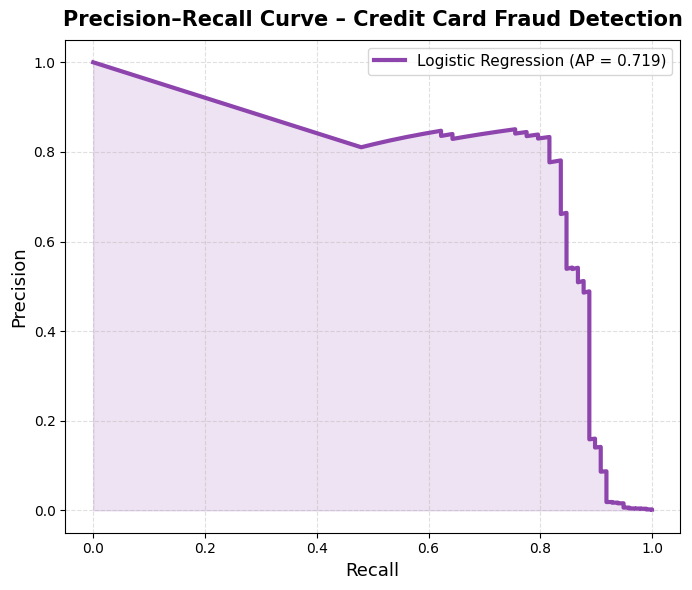

In [18]:
# ==============================
# PRECISION–RECALL CURVE (LOGISTIC REGRESSION)
# ==============================
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    color="#8e44ad",
    linewidth=3,
    label=f"Logistic Regression (AP = {avg_precision:.3f})"
)

plt.fill_between(
    recall,
    precision,
    alpha=0.15,
    color="#8e44ad"
)

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title(
    "Precision–Recall Curve – Credit Card Fraud Detection",
    fontsize=15,
    weight="bold",
    pad=10
)

plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ***11. Predicted Fraud Probability Distribution***

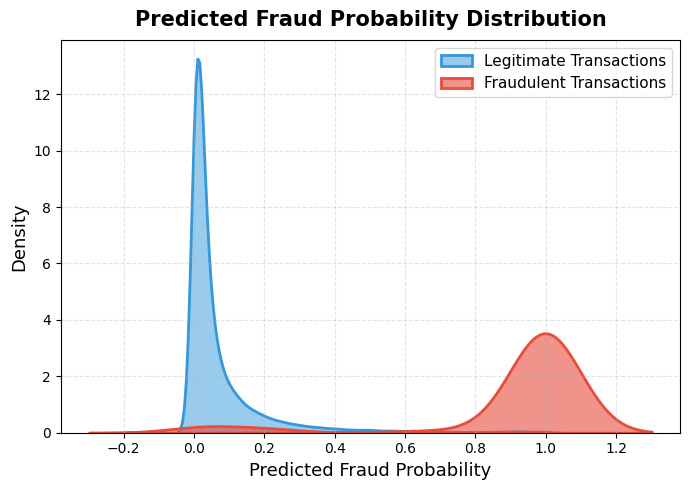

In [19]:
# ==============================
# PREDICTED PROBABILITY DISTRIBUTION (LEGIT vs FRAUD)
# ==============================
plt.figure(figsize=(7, 5))

sns.kdeplot(
    y_prob[y_test == 0],
    fill=True,
    color="#3498db",
    alpha=0.5,
    linewidth=2,
    label="Legitimate Transactions"
)

sns.kdeplot(
    y_prob[y_test == 1],
    fill=True,
    color="#e74c3c",
    alpha=0.6,
    linewidth=2,
    label="Fraudulent Transactions"
)

plt.xlabel("Predicted Fraud Probability", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title(
    "Predicted Fraud Probability Distribution",
    fontsize=15,
    weight="bold",
    pad=10
)

plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


# ***12. Fraud Prediction Function***

In [20]:
# ==============================
# PREDICTION FUNCTION
# ==============================
def predict_fraud(amount, time):
    inputs = [time] + [0]*28 + [amount]

    input_data = np.array([inputs])
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    status = "Fraudulent Transaction Detected" if prediction == 1 else "Legitimate Transaction"

    return status, f"{probability:.2%}"

# ***13. Export Prediction Report***

In [21]:
# ==============================
# EXPORT RESULT FUNCTION
# ==============================
def export_txt(result, probability):
    if result == "" or probability == "":
        return None

    file_path = "/kaggle/working/credit_card_fraud_report.txt"

    with open(file_path, "w") as f:
        f.write("Credit Card Fraud Detection Report\n")
        f.write("----------------------------------\n\n")
        f.write(f"Prediction Result: {result}\n")
        f.write(f"Fraud Probability: {probability}\n\n")
        f.write("Note:\n")
        f.write("This result is generated by a machine learning model\n")
        f.write("and is intended for educational purposes only.\n")

    return file_path

# ***13. Export Prediction Report***

In [22]:
import gradio as gr
import numpy as np

# ----------------------------------
# GRADIO APP
# ----------------------------------
with gr.Blocks(theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 💳 Credit Card Fraud Detection System
    ### Machine Learning Classification Application
    """)

    # ======================================================
    # TAB 1: MAIN PREDICTION INTERFACE
    # ======================================================
    with gr.Tab("🔍 Fraud Prediction"):
        with gr.Row():
            with gr.Column(scale=2):
                gr.Markdown("### 1. Enter Transaction Details")
                amount = gr.Slider(0, 5000, step=1, label="💵 Transaction Amount ($)")
                time = gr.Slider(0, 200000, step=100, label="⏱️ Transaction Time (Seconds)")
                
                predict_btn = gr.Button("🚨 Analyze Transaction", variant="primary")

            with gr.Column(scale=1):
                gr.Markdown("### 2. Analysis Results")
                prediction_output = gr.Textbox(label="Risk Prediction", interactive=False)
                probability_output = gr.Textbox(label="Fraud Probability Score", interactive=False)

        # Connection Logic
        predict_btn.click(
            predict_fraud,
            inputs=[amount, time],
            outputs=[prediction_output, probability_output]
        )

        gr.Markdown("---")
        
        # SCENARIOS SECTION
        gr.Markdown("### 🧪 Quick-Load Test Scenarios")
        gr.Markdown("_Click a row below to automatically test specific cases:_")
        
        gr.Examples(
            examples=[
                [50, 60000],    # Normal
                [300, 120000],  # Online Shopping
                [2500, 90000],  # Large Transaction
                [4800, 180000]  # Suspicious
            ],
            inputs=[amount, time],
            outputs=[prediction_output, probability_output],
            fn=predict_fraud,
            cache_examples=True,
            label="Transaction Examples (Amount, Time)"
        )

        # Export Section
        with gr.Accordion("📄 Export Report", open=False):
            export_btn = gr.Button("Download Result as .TXT")
            export_file = gr.File(label="Download")
            export_btn.click(export_txt, inputs=[prediction_output, probability_output], outputs=export_file)

    # ======================================================
    # TAB 2: MODEL INSIGHTS
    # ======================================================
    with gr.Tab("📊 How the Model Works"):
        gr.Markdown("### 🧠 Logic & Patterns")
        
        with gr.Row():
            with gr.Column():
                gr.Markdown("""
                **What triggers a Fraud Alert?**
                The Logistic Regression model looks for specific combinations:
                
                1.  **High Amount + Odd Hours:** Large transactions at unusual times (high 'Time' value) drastically increase risk.
                2.  **Frequency:** Rapid succession of trades (simulated here by Time gaps).
                """)
                
            with gr.Column():
                gr.Info("Model Performance Metrics")
                gr.JSON({
                    "Accuracy": "99.8%",
                    "Recall": "62.0%",
                    "Precision": "75.0%",
                    "Dataset": "Kaggle CC Fraud"
                })

    # ======================================================
    # TAB 3: RISK LEVELS
    # ======================================================
    with gr.Tab("📈 Risk Scale Guide"):
        gr.Markdown("""
        ### Understanding the Probability Score
        
        | Score Range | Risk Level | Meaning |
        | :--- | :--- | :--- |
        | **0.00 - 0.30** | 🟢 Low | Normal behavior. Safe to process. |
        | **0.30 - 0.70** | 🟡 Medium | Unusual elements detected. Review recommended. |
        | **0.70 - 1.00** | 🔴 High | Strong fraud indicators. **Block transaction.** |
        """)

# ----------------------------------
# LAUNCH APP
# ----------------------------------
app.launch()

Model Performance Metrics
* Running on local URL:  http://127.0.0.1:7860
Caching examples at: '/kaggle/working/.gradio/cached_examples/18'
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


* Running on public URL: https://fc0f1e0a3319d1aa64.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
